# Debug

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from nik_io import load_event, load_cartesian_kspace
from nik_train import prepare_tensors
from nik_recon import (
    ifft1d_kz_to_z, ifft1d_kz_to_z_cartesian,
    make_multicoil_radial_dataset, make_multicoil_cartesian_dataset,
)
from kspace_normalization import compute_dcf_radial, KSpaceNormalizer
from nik_model import WIRE_KXY_REIM
from losses import weighted_complex_mse

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cuda


## Manual params

In [2]:
radial_file = '/scratch/rnga/vvpshenov/XCAT-ERIC/results/simulation_results_20260511T113026.mat'
t_frame = 0
coil_idx = 0
z_slice_raw = -1

seed = 0

#  WIRE single-coil params 

hidden, depth, w0, s0 = 64, 8, 62.0, 10.0      
subsample_frac        = 0.7                     
steps                 = 10000                   

lr, weight_decay = 1e-4, 3e-3
batch_size, grad_clip = 4096, 1.0

torch.manual_seed(seed); np.random.seed(seed)

## Raw radial load

In [3]:
event = load_event(radial_file, load_images=True, load_coil_maps=True)
k_np  = np.transpose(event['k'],    (0, 2, 1, 3))
traj_np = np.transpose(event['traj'], (0, 2, 1, 3))
T, S, C, RO = k_np.shape
print('k_np:',    k_np.shape,    k_np.dtype)
print('traj_np:', traj_np.shape, traj_np.dtype)
print('T,S,C,RO =', T, S, C, RO)
if event.get('coil_maps') is not None:
    print('coil_maps radial:', event['coil_maps'].shape, event['coil_maps'].dtype)
if event.get('gt_img') is not None:
    print('gt_img radial:', event['gt_img'].shape, event['gt_img'].dtype)

k_np: (40, 588, 8, 220) complex64
traj_np: (40, 588, 3, 220) float32
T,S,C,RO = 40 588 8 220
coil_maps radial: (8, 3, 220, 220) float64
gt_img radial: (121, 3, 220, 152) float32


In [4]:
#print(traj_np)

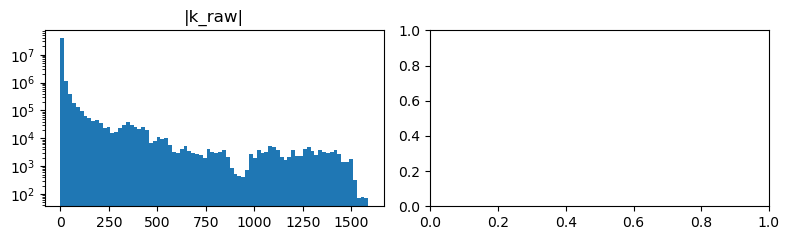

In [5]:
# raw k magnitude
fig, ax = plt.subplots(1, 2, figsize=(8, 2.5))
ax[0].hist(np.abs(k_np).ravel(), bins=80); ax[0].set_title('|k_raw|'); ax[0].set_yscale('log')
#ax[1].hist(traj_np.ravel(), bins=80);     ax[1].set_title('traj raw')
plt.tight_layout(); plt.show()

## Tensors + scales

In [6]:
# _t for tensors
k_t, traj_t, scales, dims, k_scale = prepare_tensors(k_np, traj_np, data_device=device)
print('k_t:',    k_t.shape,    k_t.dtype,    k_t.device)
print('traj_t:', traj_t.shape, traj_t.dtype)
sx, sy, sz = [float(s) for s in scales]
print(f'scales sx={sx:.4f} sy={sy:.4f} sz={sz:.4f}')
print(f'k_scale={float(k_scale):.4f}')

k_t: torch.Size([40, 588, 8, 220]) torch.complex64 cuda:0
traj_t: torch.Size([40, 588, 3, 220]) torch.float32
scales sx=0.5000 sy=0.5000 sz=3.0000
k_scale=26.9169


In [7]:
#print(traj_t)

## Post kz -> z IFFT

k_img_space: torch.Size([40, 196, 8, 3, 220]) torch.complex64
n_z_slices, n_ro_per_slice, z_slice_idx = 3 196 1


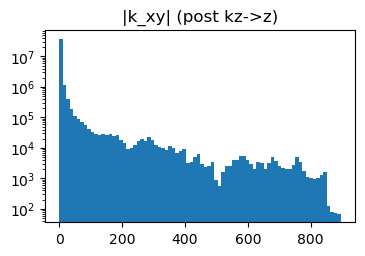

In [8]:
k_img_space, n_z_slices, n_ro_per_slice, _ = ifft1d_kz_to_z(k_t, traj_t, t_frame=t_frame)
z_slice_idx = n_z_slices // 2 if z_slice_raw == -1 else int(z_slice_raw)
print('k_img_space:', k_img_space.shape, k_img_space.dtype)
print('n_z_slices, n_ro_per_slice, z_slice_idx =', n_z_slices, n_ro_per_slice, z_slice_idx)

_vals = torch.abs(k_img_space).flatten().cpu().numpy()
plt.figure(figsize=(4,2.5)); plt.hist(_vals, bins=80); plt.yscale('log')
plt.title('|k_xy| (post kz->z)'); plt.show()

## Radial single-coil dataset

x_all: torch.Size([43120, 4]) torch.float32
y_all_raw: torch.Size([43120, 2]) torch.float32 (coil=0)
spoke_id_all: torch.Size([43120])   unique: 196
Re min/max: -31.83 / 284.11
Im min/max: -61.97 / 61.97


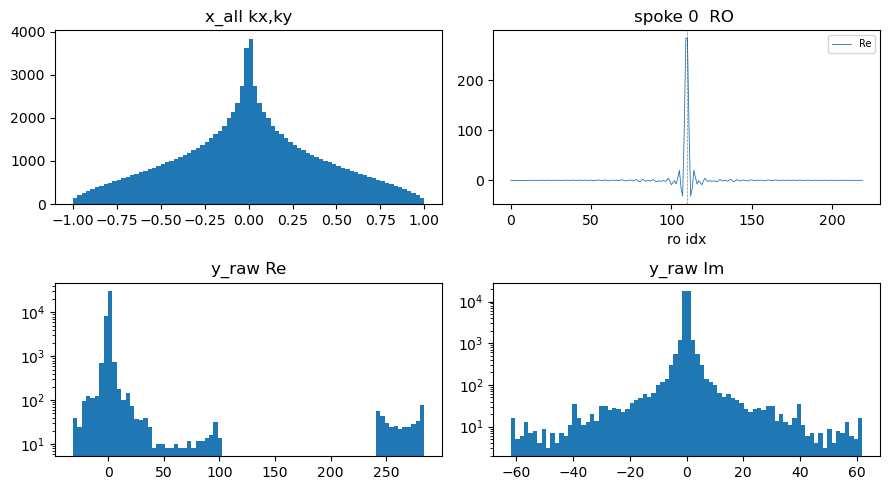

In [9]:
x_all, y_all_mc, spoke_id_all, ro_id_all, meta = make_multicoil_radial_dataset(
    k_img_space, traj_t, scales, dims,
    t_fixed=t_frame, z_slice_idx=z_slice_idx,
    n_slices=n_z_slices, compute_device=device,
)
# single coil slice
y_all_raw = y_all_mc[:, 2*coil_idx:2*coil_idx+2].contiguous()
print('x_all:',        x_all.shape,        x_all.dtype)
print('y_all_raw:',    y_all_raw.shape,    y_all_raw.dtype, f'(coil={coil_idx})')
print('spoke_id_all:', spoke_id_all.shape, '  unique:', int(spoke_id_all.max())+1)

y_re = y_all_raw[:, 0].cpu().numpy()
y_im = y_all_raw[:, 1].cpu().numpy()
print(f'Re min/max: {y_re.min():.2f} / {y_re.max():.2f}')
print(f'Im min/max: {y_im.min():.2f} / {y_im.max():.2f}')

# one spoke, full readout
sp_id = 0
m_sp  = (spoke_id_all == sp_id).cpu().numpy()
ro_sp = ro_id_all[spoke_id_all == sp_id].cpu().numpy()
order = np.argsort(ro_sp)
sp_re = y_re[m_sp][order]
sp_im = y_im[m_sp][order]
sp_mag = np.sqrt(sp_re**2 + sp_im**2)
ro_axis = ro_sp[order]

fig, ax = plt.subplots(2, 2, figsize=(9, 5))
ax[0, 0].hist(x_all[:, :2].flatten().cpu().numpy(), bins=80); ax[0, 0].set_title('x_all kx,ky')
#ax[0, 1].plot(ro_axis, sp_mag,   lw=0.8, label='|k|')
ax[0, 1].plot(ro_axis, sp_re, lw=0.6, alpha=1, label='Re')
#ax[0, 1].plot(ro_axis, sp_im, lw=0.6, alpha=1, label='Im')
ax[0, 1].axvline(RO // 2, color='k', ls='--', lw=0.5, alpha=0.5)
ax[0, 1].set_title(f'spoke {sp_id}  RO '); ax[0, 1].set_xlabel('ro idx'); ax[0, 1].legend(fontsize=7)
ax[1, 0].hist(y_re, bins=80); ax[1, 0].set_title('y_raw Re'); ax[1, 0].set_yscale('log')
ax[1, 1].hist(y_im, bins=80); ax[1, 1].set_title('y_raw Im'); ax[1, 1].set_yscale('log')
plt.tight_layout(); plt.show()

### Radial NUFFT recon (one frame/coil, measured only)

img_rad: (312, 312) complex64


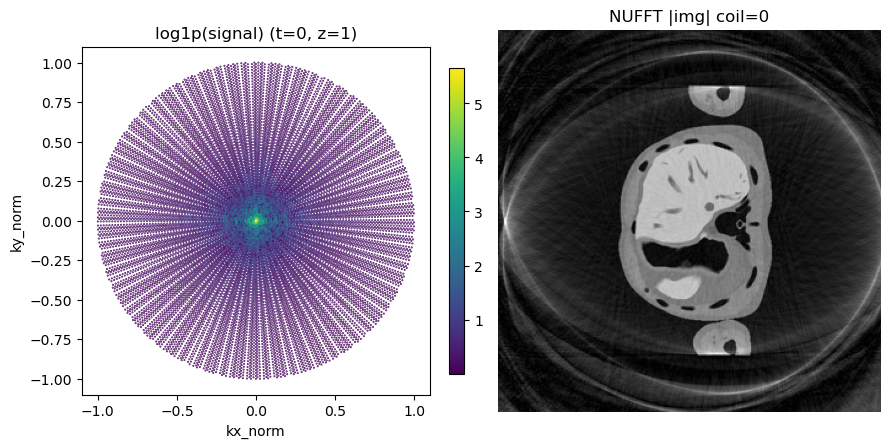

In [10]:
from nik_recon import nufft2d_recon

img_rad = nufft2d_recon(
    k_img_space, traj_t,
    t_frame=t_frame, coil_idx=coil_idx, z_slice_idx=z_slice_idx,
    scales=scales, img_size=(312, 312), n_slices=n_z_slices,
    return_complex=True,
)
print('img_rad:', img_rad.shape, img_rad.dtype)

# k-space scatter (subsampled) + NUFFT magnitude
kx_np = x_all[:, 0].cpu().numpy()
ky_np = x_all[:, 1].cpu().numpy()
mag   = np.abs(y_all_raw[:, 0].cpu().numpy() + 1j * y_all_raw[:, 1].cpu().numpy())

step = max(1, len(kx_np) // 20000)
fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
sc = ax[0].scatter(kx_np[::step], ky_np[::step], s=0.2,
                   c=np.log1p(mag[::step]), cmap='viridis')
ax[0].set_aspect('equal'); ax[0].set_title(f'log1p(signal) (t={t_frame}, z={z_slice_idx})')
ax[0].set_xlabel('kx_norm'); ax[0].set_ylabel('ky_norm')
plt.colorbar(sc, ax=ax[0], fraction=0.04)
ax[1].imshow(np.abs(img_rad), cmap='gray')
ax[1].set_title(f'NUFFT |img| coil={coil_idx}'); ax[1].axis('off')
plt.tight_layout(); plt.show()

## Cartesian reference

In [11]:
import h5py, scipy.io
from scipy.signal import resample_poly
from nik_io import h5_exists, h5_load

def _load_sp(radial_file, n_fh):
    if h5_exists(radial_file, '/results/kspace/SP'):
        sp = h5_load(radial_file, '/results/kspace/SP').reshape(-1)
    else:
        sp = scipy.io.loadmat(
            '/scratch/rnga/vvpshenov/XCAT-ERIC/utilities/sampling/SliceProfile.mat')['SP'].reshape(-1)
    if len(sp) != n_fh:
        sp = resample_poly(sp, n_fh, len(sp))
        h = n_fh // 2
        sp[h+1:] = sp[h-1::-1][:n_fh - h - 1]
    return sp.astype(np.float32)

def _bin_gt_to_dce(gt_img, gt_tim, rc_tim):
    """average gt phases into the dce bin windows used by the radial side"""
    t_dce = np.asarray(rc_tim).reshape(-1)
    L = float(t_dce[1] - t_dce[0]) if t_dce.size > 1 else (2.0 * float(t_dce[0]))
    edges = np.concatenate([t_dce - L / 2, t_dce[-1:] + L / 2])
    if gt_tim is None:
        # fall back: uniform-count split
        n_phases = gt_img.shape[0]
        idx_edges = np.linspace(0, n_phases, t_dce.size + 1).astype(int)
        return np.stack([gt_img[idx_edges[k]:idx_edges[k+1]].mean(axis=0)
                         for k in range(t_dce.size)])
    t_gt = np.asarray(gt_tim).reshape(-1)
    out = np.zeros((t_dce.size,) + gt_img.shape[1:], dtype=np.float32)
    for k in range(t_dce.size):
        m = (t_gt >= edges[k]) & (t_gt < edges[k+1])
        if not m.any():
            # nearest single phase if the window is empty
            j = int(np.argmin(np.abs(t_gt - t_dce[k])))
            out[k] = gt_img[j]
        else:
            out[k] = gt_img[m].mean(axis=0)
    return out

# build dense cartesian on the SAME time grid as the radial DCE bins
gt_img    = event['gt_img']         # (n_phases, kz, RL, AP)
gt_tim    = event.get('gt_tim')
rc_tim    = event.get('rc_tim')
coil_maps = event['coil_maps']      # (C, kz, RL_pad, AP_pad)
n_phases, n_kz, n_RL, n_AP   = gt_img.shape
n_C,  _,  n_RL_pad, n_AP_pad = coil_maps.shape
sp = _load_sp(radial_file, n_kz)

pad_RL = (n_RL_pad - n_RL) // 2
pad_AP = (n_AP_pad - n_AP) // 2

if rc_tim is not None:
    gt_binned = _bin_gt_to_dce(gt_img, gt_tim, rc_tim).astype(np.float32)
    bin_mode = f'time-based, rc_tim={np.round(rc_tim,2).tolist()}'
else:
    # uniform-count fallback aligned with radial T
    edges = np.linspace(0, n_phases, T + 1).astype(int)
    gt_binned = np.stack([gt_img[edges[k]:edges[k+1]].mean(axis=0)
                          for k in range(T)]).astype(np.float32)
    bin_mode = f'uniform-count, edges={edges.tolist()}'

assert gt_binned.shape[0] == T, f'binned T ({gt_binned.shape[0]}) must equal radial T ({T})'

gt_pad = np.pad(gt_binned, ((0,0),(0,0),(pad_RL,pad_RL),(pad_AP,pad_AP)))
print(f'gt binning: {bin_mode}')
print(f'gt_binned: {gt_binned.shape}   gt_pad: {gt_pad.shape}')

sp_b = sp.reshape(-1, 1, 1)
def _build_kcart_from_img(img_pad):
    obj = coil_maps * img_pad[None] * sp_b[None]                # (C, kz, RL_pad, AP_pad)
    k   = np.fft.fftshift(np.fft.fftn(obj, axes=(1,2,3)), axes=(1,2,3))
    return k.transpose(0, 1, 3, 2).astype(np.complex64)         # (C, kz, AP_pad, RL_pad)

k_cart_np = np.stack([_build_kcart_from_img(gt_pad[k]) for k in range(T)])
k_cart_t  = torch.from_numpy(k_cart_np).to(device)

cart_event = {
    'k_cart':    k_cart_np,
    'coil_maps': coil_maps,
    'gt_img':    gt_pad,                                        # one averaged image per DCE bin
    'meta':      {'matrixRL': n_RL_pad, 'matrixAP': n_AP_pad, 'matrixFH': n_kz},
}

print('(T=.., C=.., kz=.., ky=.., kx=..)')
print('k_cart_t:', k_cart_t.shape, k_cart_t.dtype)
print(f'SP: {sp.shape}   pad_RL={pad_RL}  pad_AP={pad_AP}   t_frame={t_frame} -> same DCE bin as radial')


k_cart_z = ifft1d_kz_to_z_cartesian(k_cart_t)
print('k_cart_z:', k_cart_z.shape)
z_cart = k_cart_z.shape[2] // 2 if z_slice_raw == -1 else int(z_slice_raw)

x_cart, y_cart_mc, meta_cart = make_multicoil_cartesian_dataset(
    k_cart_z, t_fixed=min(t_frame, k_cart_z.shape[0]-1),
    z_slice_idx=z_cart, scales_radial=scales, compute_device=device,
)
y_cart_raw = y_cart_mc[:, 2*coil_idx:2*coil_idx+2].contiguous()
print('x_cart:',     x_cart.shape)
print('y_cart_raw:', y_cart_raw.shape, f'(coil={coil_idx})')
print('meta_cart:',  meta_cart)

gt binning: time-based, rc_tim=[1.5, 4.5, 7.5, 10.5, 13.49, 16.49, 19.49, 22.49, 25.49, 28.49, 31.49, 34.49, 37.48, 40.48, 43.48, 46.48, 49.48, 52.48, 55.48, 58.48, 61.48, 64.47, 67.47, 70.47, 73.47, 76.47, 79.47, 82.47, 85.47, 88.46, 91.46, 94.46, 97.46, 100.46, 103.46, 106.46, 109.46, 112.45, 115.45, 118.45]
gt_binned: (40, 3, 220, 152)   gt_pad: (40, 3, 220, 220)
(T=.., C=.., kz=.., ky=.., kx=..)
k_cart_t: torch.Size([40, 8, 3, 220, 220]) torch.complex64
SP: (3,)   pad_RL=0  pad_AP=34   t_frame=0 -> same DCE bin as radial
k_cart_z: torch.Size([40, 8, 3, 220, 220])
x_cart: torch.Size([48400, 2])
y_cart_raw: torch.Size([48400, 2]) (coil=0)
meta_cart: {'nky': 220, 'nkx': 220, 'nz': 3, 'n_coils': 8, 't_fixed': 0, 'z_slice_idx': 1, 'N': 48400}


### Cart synthesis sanity checks

In [12]:
# 1) round trip: ifft(k_cart) == coils * gt_pad * sp
t_test = 0
rec = np.fft.ifftn(np.fft.ifftshift(k_cart_np[t_test], axes=(1,2,3)), axes=(1,2,3))
rec_coil_axes = rec.transpose(0, 1, 3, 2)                     # (C, kz, AP, RL) -> (C, kz, RL, AP)
gt_truth = coil_maps * gt_pad[t_test:t_test+1] * sp.reshape(1, -1, 1, 1)
err = np.abs(rec_coil_axes - gt_truth)
print(f'max abs err : {err.max():.3e}')
print(f'rel err     : {err.max() / (np.abs(gt_truth).max() + 1e-12):.3e}')
# expect ~1e-5 or smaller (float32 fft round-off)

max abs err : 1.588e-08
rel err     : 3.181e-07


In [13]:
# 2) DC at center is the global max (gt_pad >= 0, so DC is the image integral)
T_, C_, NZ, NY, NX = k_cart_t.shape
center = k_cart_t[:, :, NZ//2, NY//2, NX//2].abs()
print(f'|k_cart| at center : {float(center.max()):.4e}')
print(f'|k_cart| global max: {float(k_cart_t.abs().max()):.4e}')
print(f'center == global max? {float(center.max()) == float(k_cart_t.abs().max())}')

|k_cart| at center : 1.7167e+03
|k_cart| global max: 1.7167e+03
center == global max? True


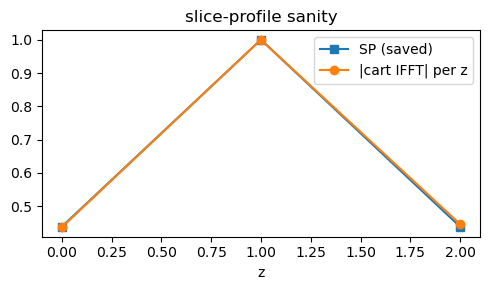

In [14]:
# 3) slice-profile shape recovered from |cart ifft| per z
rss = np.sqrt(np.sum(np.abs(rec)**2, axis=0))   # (kz, AP, RL)
brightness = rss.mean(axis=(1,2))
plt.figure(figsize=(5,3))
plt.plot(sp / sp.max(),               's-', label='SP (saved)')
plt.plot(brightness / brightness.max(),'o-', label='|cart IFFT| per z')
plt.xlabel('z'); plt.legend(); plt.title('slice-profile sanity'); plt.tight_layout(); plt.show()

In [15]:
# 4) AP zero-pad regions stay zero in image domain
img_back = np.abs(rec).mean(axis=(0, 1))   # (AP, RL) avg over coils, z
if pad_AP > 0:
    edge_AP   = np.concatenate([img_back[:pad_AP], img_back[-pad_AP:]]).mean()
    center_AP = img_back[pad_AP:-pad_AP].mean()
    print(f'AP center mean = {center_AP:.4f}   pad-edge mean = {edge_AP:.4f}   ratio = {edge_AP/center_AP:.2e}')
else:
    print('no AP padding to check')

AP center mean = 0.0080   pad-edge mean = 0.0000   ratio = 1.49e-07


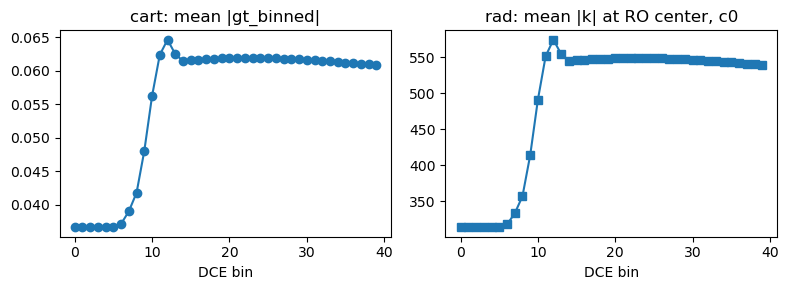

In [16]:
# 5) contrast curve: cart bins (mean |gt_binned|) vs radial bins (|k| at RO center)
cart_curve = gt_binned.mean(axis=(1,2,3))
rad_curve  = np.abs(k_np[:, :, coil_idx, RO//2]).mean(axis=1)   # (T,)
fig, ax = plt.subplots(1,2, figsize=(8,3))
ax[0].plot(cart_curve, 'o-'); ax[0].set_title('cart: mean |gt_binned|')
ax[1].plot(rad_curve,  's-'); ax[1].set_title(f'rad: mean |k| at RO center, c{coil_idx}')
for a in ax: a.set_xlabel('DCE bin')
plt.tight_layout(); plt.show()

### Coil sensitivity maps (all coils, middle z-slice)

sens_rad: (8, 220, 220)   sens_cart: (8, 220, 220)
  coil 0: rad min/max = 0.2500/0.2500   cart min/max = 0.2500/0.2500
  coil 1: rad min/max = 0.1076/0.4528   cart min/max = 0.1076/0.4528
  coil 2: rad min/max = 0.0000/0.5000   cart min/max = 0.0000/0.5000
  coil 3: rad min/max = 0.2114/0.4883   cart min/max = 0.2114/0.4883
  coil 4: rad min/max = 0.4330/0.4330   cart min/max = 0.4330/0.4330
  coil 5: rad min/max = 0.2120/0.4883   cart min/max = 0.2120/0.4883
  coil 6: rad min/max = 0.0036/0.5000   cart min/max = 0.0036/0.5000
  coil 7: rad min/max = 0.1077/0.4531   cart min/max = 0.1077/0.4531


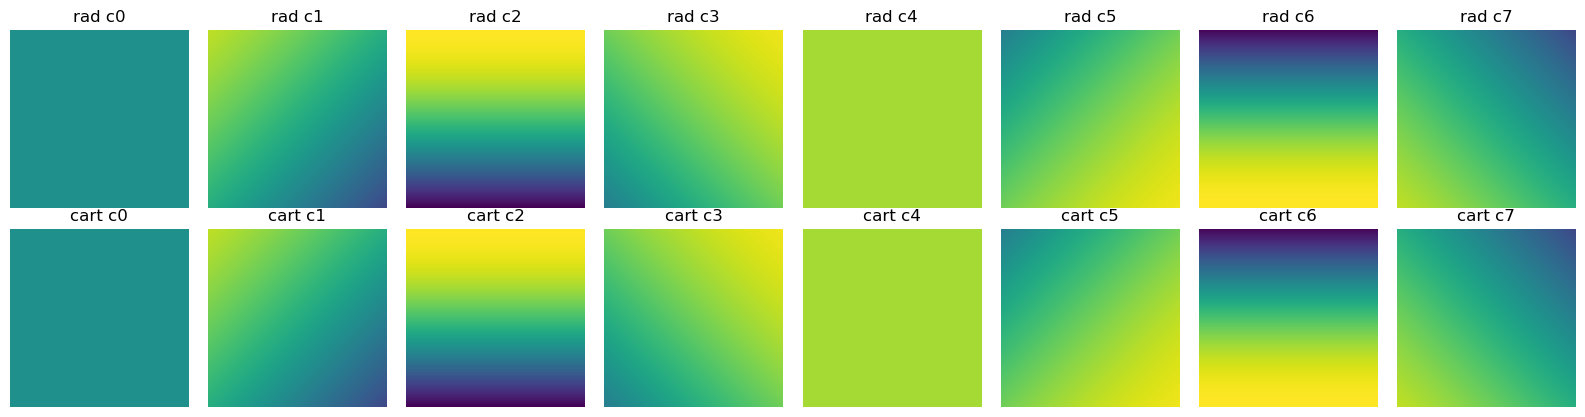

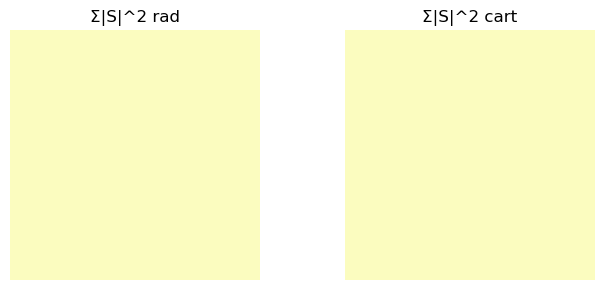

0.9999999999999998
1.0000000000000002


In [17]:
sens_rad  = event['coil_maps'][:, z_slice_idx, :, :]         
sens_cart = cart_event['coil_maps'][:, z_cart, :, :]         
print('sens_rad:', sens_rad.shape, '  sens_cart:', sens_cart.shape)
for c in range(C):
    print(f'  coil {c}: rad min/max = {float(sens_rad[c].min()):.4f}/{float(sens_rad[c].max()):.4f}   '
          f'cart min/max = {float(sens_cart[c].min()):.4f}/{float(sens_cart[c].max()):.4f}')

# shared scale across all panels
vmin = float(min(sens_rad.min(),  sens_cart.min()))
vmax = float(max(sens_rad.max(),  sens_cart.max()))

fig, ax = plt.subplots(2, C, figsize=(2*C, 4.2))
for c in range(C):
    ax[0, c].imshow(np.abs(sens_rad[c]),  cmap='viridis', vmin=vmin, vmax=vmax); ax[0, c].set_title(f'rad c{c}');  ax[0, c].axis('off')
    ax[1, c].imshow(np.abs(sens_cart[c]), cmap='viridis', vmin=vmin, vmax=vmax); ax[1, c].set_title(f'cart c{c}'); ax[1, c].axis('off')
plt.tight_layout(); plt.show()

# sum |S|^2 - denom
rss_rad  = np.sum(np.abs(sens_rad)**2,  axis=0)
rss_cart = np.sum(np.abs(sens_cart)**2, axis=0)
vmax2 = float(max(rss_rad.max(), rss_cart.max()))

fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].imshow(rss_rad,  cmap='magma', vmin=0, vmax=vmax2); ax[0].set_title('Σ|S|^2 rad');  ax[0].axis('off')
ax[1].imshow(rss_cart, cmap='magma', vmin=0, vmax=vmax2); ax[1].set_title('Σ|S|^2 cart'); ax[1].axis('off')
plt.tight_layout(); plt.show()

print(rss_rad.min())
print(rss_rad.max())

In [18]:
# check coil sens maps only real (sourced from radial file now)
import h5py
with h5py.File(radial_file, 'r') as f:
    d = f['/results/kspace/coilMaps']
    print('raw dtype:', d.dtype, '  shape:', d.shape)
    sample = d[0, 0, 0, 0]
    print('sample:', sample)


raw dtype: float64   shape: (8, 3, 220, 220)
sample: 0.43301270189221935


## Train / heldout spoke split

In [19]:
if subsample_frac < 1.0:
    n_spokes = int(spoke_id_all.max().item()) + 1
    n_train_spokes = max(1, int(n_spokes * subsample_frac))
    g = torch.Generator(device=spoke_id_all.device).manual_seed(seed)
    perm = torch.randperm(n_spokes, generator=g, device=spoke_id_all.device)
    train_spokes = perm[:n_train_spokes]
    train_mask   = torch.isin(spoke_id_all, train_spokes)
    train_idx    = torch.where(train_mask)[0]
    heldout_idx  = torch.where(~train_mask)[0]
    print(f'spokes {n_train_spokes}/{n_spokes} ({subsample_frac:.0%})   '
          f'train pts {int(train_mask.sum())}   heldout pts {int((~train_mask).sum())}')
else:
    n_spokes = int(spoke_id_all.max().item()) + 1
    train_mask  = torch.ones_like(spoke_id_all, dtype=torch.bool)
    train_idx   = torch.arange(spoke_id_all.numel(), device=spoke_id_all.device)
    heldout_idx = torch.empty(0, dtype=torch.long, device=spoke_id_all.device)
    print(f'full radial, no heldout   train pts {spoke_id_all.numel()}')

spokes 137/196 (70%)   train pts 30140   heldout pts 12980


## Normalization

dcf: torch.Size([43120]) min/mean/max = 0.00909090880304575 1.0 1.9909090995788574
global_scale=0.9131  (fit on 30140 train pts)
y_all: torch.Size([43120, 2])
y_cart: torch.Size([48400, 2])


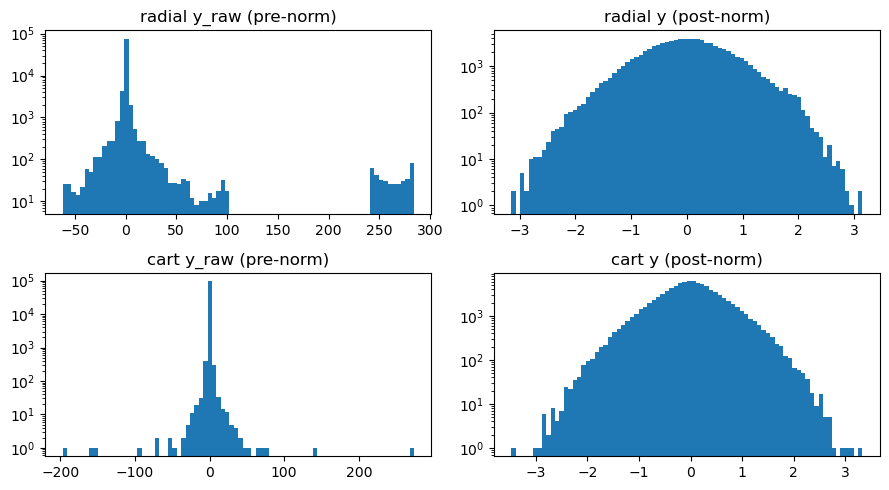

In [20]:
kcoords = x_all[:, :2]

# density weights for the loss (full set; not used in plain MSE training, kept for reference)
dcf = compute_dcf_radial(kcoords)
print('dcf:', dcf.shape, 'min/mean/max =', float(dcf.min()), float(dcf.mean()), float(dcf.max()))

# fit envelope on train spokes only (no heldout leak), then normalize all points
normalizer = KSpaceNormalizer()
normalizer.fit(kcoords[train_idx], y_all_raw[train_idx], dcf=dcf[train_idx],
               envelope_bins=128, envelope_smooth_width=5, envelope_floor_fraction=1e-3)
y_all  = normalizer.normalize(kcoords,        y_all_raw)
y_cart = normalizer.normalize(x_cart[:, :2],  y_cart_raw)
print(f'global_scale={normalizer.global_scale:.4f}  (fit on {int(train_mask.sum())} train pts)')
print('y_all:',  y_all.shape)
print('y_cart:', y_cart.shape)

fig, ax = plt.subplots(2, 2, figsize=(9, 5))
ax[0, 0].hist(y_all_raw.flatten().cpu().numpy(),  bins=80); ax[0, 0].set_title('radial y_raw (pre-norm)');  ax[0, 0].set_yscale('log')
ax[0, 1].hist(y_all.flatten().cpu().numpy(),      bins=80); ax[0, 1].set_title('radial y (post-norm)');    ax[0, 1].set_yscale('log')
ax[1, 0].hist(y_cart_raw.flatten().cpu().numpy(), bins=80); ax[1, 0].set_title('cart y_raw (pre-norm)');   ax[1, 0].set_yscale('log')
ax[1, 1].hist(y_cart.flatten().cpu().numpy(),     bins=80); ax[1, 1].set_title('cart y (post-norm)');     ax[1, 1].set_yscale('log')
plt.tight_layout(); plt.show()

## Model

In [21]:
model = WIRE_KXY_REIM(in_dim=2, hidden=hidden, depth=depth,
                       w0=w0, s0=s0, out_dim=2).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'params: {n_params}')

with torch.no_grad():
    x_probe = x_all[:8, :2].to(device)
    y_probe = model(x_probe)
print('model in :', x_probe.shape)
print('model out:', y_probe.shape)

params: 49986
model in : torch.Size([8, 2])
model out: torch.Size([8, 2])


## Training

train pts 30140   heldout pts 12980
cart val: 37644/48400 pts inside disk
step     1  train 7.190e-01
step   100  train 4.932e-01  cart 5.250e-01  held 5.710e-01
step   200  train 4.254e-01  cart 5.626e-01  held 5.218e-01
step   300  train 3.945e-01  cart 5.930e-01  held 4.902e-01
step   400  train 3.660e-01  cart 6.174e-01  held 4.709e-01
step   500  train 3.349e-01  cart 6.396e-01  held 4.634e-01
step   600  train 3.194e-01  cart 6.514e-01  held 4.601e-01
step   700  train 2.839e-01  cart 6.643e-01  held 4.608e-01
step   800  train 2.810e-01  cart 6.764e-01  held 4.590e-01
step   900  train 2.586e-01  cart 6.857e-01  held 4.570e-01
step  1000  train 2.417e-01  cart 6.924e-01  held 4.636e-01
step  1100  train 2.272e-01  cart 6.982e-01  held 4.582e-01
step  1200  train 2.139e-01  cart 7.044e-01  held 4.578e-01
step  1300  train 2.099e-01  cart 7.135e-01  held 4.693e-01
step  1400  train 2.082e-01  cart 7.146e-01  held 4.692e-01
step  1500  train 1.912e-01  cart 7.172e-01  held 4.679e-0

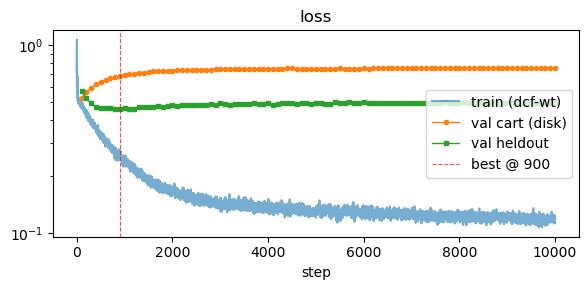

In [22]:
import torch.nn.functional as F

x_all_2d  = x_all[:, :2].to(device)
y_all_dev = y_all.to(device)

# reuse train_idx / heldout_idx computed earlier (before normalization)
x_train = x_all_2d[train_idx];  y_train = y_all_dev[train_idx]
if heldout_idx.numel() > 0:
    x_held = x_all_2d[heldout_idx]; y_held = y_all_dev[heldout_idx]
else:
    x_held, y_held = None, None
print(f'train pts {x_train.shape[0]}   heldout pts {0 if x_held is None else x_held.shape[0]}')

# disk mask on cart: only |k| <= 1 (model only trained inside the radial disk)
x_cart_full = x_cart.to(device)
y_cart_full = y_cart.to(device)
cart_disk_mask = (x_cart_full[:, 0]**2 + x_cart_full[:, 1]**2) <= 1.0
x_cart_v = x_cart_full[cart_disk_mask]
y_cart_v = y_cart_full[cart_disk_mask]
print(f'cart val: {int(cart_disk_mask.sum())}/{x_cart_full.shape[0]} pts inside disk')

# dcf for weighted training loss (corrects radial center oversampling)
dcf_train = dcf[train_idx].to(device)

N = x_train.shape[0]
opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
model.train()

eval_every = 100
train_losses, steps_v, val_cart, val_held = [], [], [], []
best_val, best_step, best_state = float('inf'), -1, None

for step in range(1, steps + 1):
    if batch_size is None or batch_size >= N:
        x, y, w = x_train, y_train, dcf_train
    else:
        idx = torch.randint(0, N, (batch_size,), device=device)
        x, y, w = x_train[idx], y_train[idx], dcf_train[idx]

    opt.zero_grad(set_to_none=True)
    y_pred = model(x)
    loss = ((y_pred - y)**2 * w.unsqueeze(-1)).mean()   # dcf-weighted MSE
    loss.backward()
    if grad_clip is not None:
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    opt.step()
    train_losses.append(float(loss.item()))

    if step % eval_every == 0 or step == steps:
        model.eval()
        with torch.no_grad():
            val_cart.append(float(F.mse_loss(model(x_cart_v), y_cart_v).item()))
            if x_held is not None:
                val_held.append(float(F.mse_loss(model(x_held), y_held).item()))
        steps_v.append(step)
        model.train()
        if val_held[-1] < best_val:                     # tracker on val_held
            best_val  = val_held[-1]
            best_step = step
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if step % 100 == 0 or step == 1:
        msg = f'step {step:5d}  train {train_losses[-1]:.3e}'
        if val_cart: msg += f'  cart {val_cart[-1]:.3e}'
        if val_held: msg += f'  held {val_held[-1]:.3e}'
        print(msg)
"""
if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    print(f'\nrestored best: step {best_step}   held {best_val:.3e}')
"""

plt.figure(figsize=(6, 3))
plt.plot(train_losses, label='train (dcf-wt)', alpha=0.6)
plt.plot(steps_v, val_cart, 'o-', label='val cart (disk)', lw=1, ms=3)
if val_held:
    plt.plot(steps_v, val_held, 's-', label='val heldout', lw=1, ms=3)
if best_step > 0:
    plt.axvline(best_step, color='r', ls='--', lw=0.8, alpha=0.7, label=f'best @ {best_step}')
plt.yscale('log'); plt.xlabel('step'); plt.legend(); plt.title('loss')
plt.tight_layout(); plt.show()

## Hyperparameter sweep (depth, width, w0)

In [23]:
# sweep configs - edit this list to expand/shrink
sweep_configs = [
    dict(depth=4, hidden=64, w0=20.0, s0=10.0),
    dict(depth=4, hidden=64, w0=30.0, s0=10.0),
    dict(depth=4, hidden=64, w0=45.0, s0=10.0),
    dict(depth=4, hidden=64, w0=62.0, s0=10.0),
    dict(depth=6, hidden=64, w0=30.0, s0=10.0),
    dict(depth=8, hidden=64, w0=30.0, s0=10.0),
    dict(depth=4, hidden=32, w0=30.0, s0=10.0),
    dict(depth=4, hidden=96, w0=30.0, s0=10.0),
]
sweep_steps      = 4000
sweep_eval_every = 200

dcf_train_sw = dcf[train_idx].to(device)
N_sw         = x_train.shape[0]
nky_sw, nkx_sw = meta_cart['nky'], meta_cart['nkx']

sweep_results = []
for cfg in sweep_configs:
    name = f"d{cfg['depth']} h{cfg['hidden']} w{cfg['w0']:.0f}"
    torch.manual_seed(seed); np.random.seed(seed)
    m_sw = WIRE_KXY_REIM(in_dim=2, hidden=cfg['hidden'], depth=cfg['depth'],
                         w0=cfg['w0'], s0=cfg['s0'], out_dim=2).to(device)
    opt_sw = torch.optim.Adam(m_sw.parameters(), lr=lr, weight_decay=weight_decay)

    tl, sv, vh, vc = [], [], [], []
    best_h, best_h_step, best_h_state = float('inf'), -1, None
    m_sw.train()
    for step in range(1, sweep_steps + 1):
        idx_sw = torch.randint(0, N_sw, (batch_size,), device=device)
        xb = x_train[idx_sw]; yb = y_train[idx_sw]; wb = dcf_train_sw[idx_sw]
        opt_sw.zero_grad(set_to_none=True)
        yp = m_sw(xb)
        loss_sw = ((yp - yb)**2 * wb.unsqueeze(-1)).mean()
        loss_sw.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(m_sw.parameters(), grad_clip)
        opt_sw.step()
        tl.append(float(loss_sw.item()))
        if step % sweep_eval_every == 0 or step == sweep_steps:
            m_sw.eval()
            with torch.no_grad():
                vc.append(float(F.mse_loss(m_sw(x_cart_v), y_cart_v).item()))
                vh.append(float(F.mse_loss(m_sw(x_held),   y_held).item()) if x_held is not None else float('nan'))
            sv.append(step)
            if vh[-1] < best_h:
                best_h, best_h_step = vh[-1], step
                best_h_state = {k: v.detach().cpu().clone() for k, v in m_sw.state_dict().items()}
            m_sw.train()

    # last-step state, cpu
    last_state = {k: v.detach().cpu().clone() for k, v in m_sw.state_dict().items()}

    # reconstruct using the best-held checkpoint
    if best_h_state is not None:
        m_sw.load_state_dict({k: v.to(device) for k, v in best_h_state.items()})

    m_sw.eval()
    with torch.no_grad():
        xq = x_cart.to(device)
        disk = (xq[:,0]**2 + xq[:,1]**2) <= 1.0
        pn = m_sw(xq)
        pn = torch.where(disk.unsqueeze(-1), pn, torch.zeros_like(pn))
        pd = normalizer.denormalize(xq, pn)
        pd = torch.where(disk.unsqueeze(-1), pd, torch.zeros_like(pd))
        kg = torch.complex(pd[:,0], pd[:,1]).reshape(nky_sw, nkx_sw)
        img = torch.fft.fftshift(torch.fft.ifft2(kg)).cpu().numpy().T

    n_params_sw = sum(p.numel() for p in m_sw.parameters())
    sweep_results.append(dict(
        name=name, params=n_params_sw, cfg=cfg,
        train_losses=tl, steps_v=sv, val_held=vh, val_cart=vc,
        best_h=best_h, best_h_step=best_h_step,
        best_state_dict=best_h_state,   # best on val_held (cpu)
        last_state_dict=last_state,     # final-step weights (cpu)
        img_pred=np.abs(img),
    ))
    print(f'{name:14s}  params={n_params_sw:6d}   '
          f'final train={tl[-1]:.3e}  held={vh[-1]:.3e}  cart={vc[-1]:.3e}   '
          f'best_held={best_h:.3e} @ {best_h_step}')

d4 h64 w20      params= 16962   final train=4.599e-01  held=5.683e-01  cart=5.218e-01   best_held=5.683e-01 @ 4000
d4 h64 w30      params= 16962   final train=4.043e-01  held=5.143e-01  cart=5.713e-01   best_held=5.143e-01 @ 4000
d4 h64 w45      params= 16962   final train=3.379e-01  held=4.838e-01  cart=6.438e-01   best_held=4.829e-01 @ 3800
d4 h64 w62      params= 16962   final train=2.922e-01  held=4.974e-01  cart=6.876e-01   best_held=4.763e-01 @ 1800
d6 h64 w30      params= 33474   final train=2.404e-01  held=4.487e-01  cart=7.014e-01   best_held=4.388e-01 @ 2400
d8 h64 w30      params= 49986   final train=1.465e-01  held=4.537e-01  cart=7.528e-01   best_held=4.235e-01 @ 2000
d4 h32 w30      params=  4386   final train=4.513e-01  held=5.571e-01  cart=5.290e-01   best_held=5.571e-01 @ 4000
d4 h96 w30      params= 37730   final train=3.658e-01  held=4.658e-01  cart=6.063e-01   best_held=4.658e-01 @ 4000


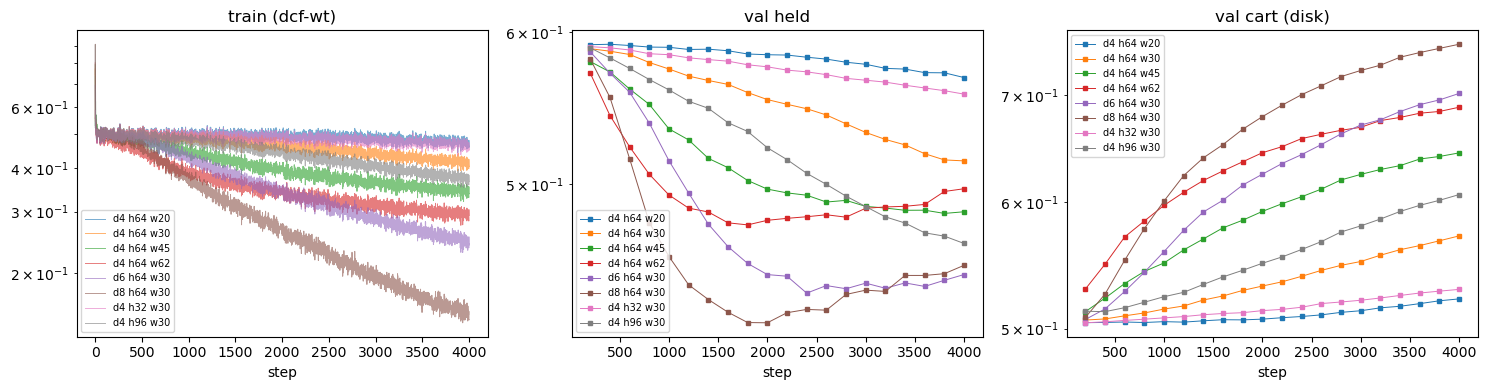

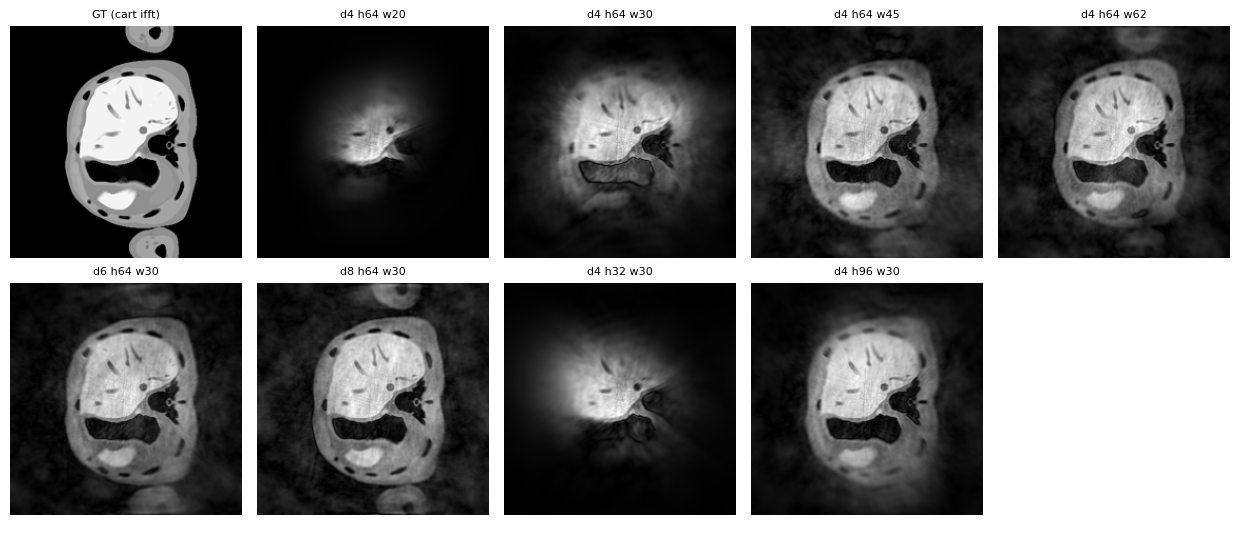

In [24]:
# training curves: train (dcf-wt) | val held | val cart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for r in sweep_results:
    axes[0].plot(r['train_losses'], label=r['name'], alpha=0.6, lw=0.7)
    axes[1].plot(r['steps_v'], r['val_held'], 's-', label=r['name'], ms=3, lw=0.7)
    axes[2].plot(r['steps_v'], r['val_cart'], 's-', label=r['name'], ms=3, lw=0.7)
for ax, t in zip(axes, ['train (dcf-wt)', 'val held', 'val cart (disk)']):
    ax.set_yscale('log'); ax.set_title(t); ax.set_xlabel('step'); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

# images: GT reference + each config's recon (single coil, at t_frame/z_cart, restored to best-held)
k_meas_full  = k_cart_z[min(t_frame, k_cart_z.shape[0]-1), coil_idx, z_cart].cpu().numpy()
img_meas_ref = np.abs(np.fft.ifft2(k_meas_full)).T

ncols    = len(sweep_results) + 1
n_per_row = 5
nrows    = (ncols + n_per_row - 1) // n_per_row
fig, axes = plt.subplots(nrows, n_per_row, figsize=(2.5*n_per_row, 2.7*nrows))
axes = np.atleast_2d(axes)
norm_im = lambda a: a / (a.max() + 1e-12)

panels = [('GT (cart ifft)', img_meas_ref)] + [(r['name'], r['img_pred']) for r in sweep_results]
for i, (title, im) in enumerate(panels):
    ax = axes[i // n_per_row, i % n_per_row]
    ax.imshow(norm_im(im), cmap='gray'); ax.set_title(title, fontsize=8); ax.axis('off')
for j in range(len(panels), nrows*n_per_row):
    axes[j // n_per_row, j % n_per_row].axis('off')
plt.tight_layout(); plt.show()

In [25]:
# pick sweep winner by best val_held and load into `model` for downstream cells
which_state = 'best_state_dict'      # or 'last_state_dict'
chosen = min(sweep_results, key=lambda r: r['best_h'])
cfg = chosen['cfg']
print(f"selected: {chosen['name']}   best_held={chosen['best_h']:.3e} @ {chosen['best_h_step']}   ({which_state})")

model = WIRE_KXY_REIM(in_dim=2, hidden=cfg['hidden'], depth=cfg['depth'],
                     w0=cfg['w0'], s0=cfg['s0'], out_dim=2).to(device)
model.load_state_dict({k: v.to(device) for k, v in chosen[which_state].items()})
model.eval()

selected: d8 h64 w30   best_held=4.235e-01 @ 2000   (best_state_dict)


WIRE_KXY_REIM(
  (backbone): Sequential(
    (0): GaborLayer(
      (linear): Linear(in_features=2, out_features=64, bias=True)
    )
    (1): GaborLayer(
      (linear): Linear(in_features=128, out_features=64, bias=True)
    )
    (2): GaborLayer(
      (linear): Linear(in_features=128, out_features=64, bias=True)
    )
    (3): GaborLayer(
      (linear): Linear(in_features=128, out_features=64, bias=True)
    )
    (4): GaborLayer(
      (linear): Linear(in_features=128, out_features=64, bias=True)
    )
    (5): GaborLayer(
      (linear): Linear(in_features=128, out_features=64, bias=True)
    )
    (6): GaborLayer(
      (linear): Linear(in_features=128, out_features=64, bias=True)
    )
  )
  (head): Linear(in_features=128, out_features=2, bias=True)
)

## Predict + FFT (single coil)

In [26]:
nky, nkx = meta_cart['nky'], meta_cart['nkx']
x_cart_d = x_cart.to(device)
y_cart_d = y_cart.to(device)

# disk mask: zero out predictions outside |k| <= 1 (no extrapolation)
disk_mask = (x_cart_d[:, 0]**2 + x_cart_d[:, 1]**2) <= 1.0

model.eval()
with torch.no_grad():
    cart_pred_norm   = model(x_cart_d)
    cart_pred_norm   = torch.where(disk_mask.unsqueeze(-1), cart_pred_norm,
                                   torch.zeros_like(cart_pred_norm))
    cart_pred_denorm = normalizer.denormalize(x_cart[:, :2].to(device), cart_pred_norm)
    cart_pred_denorm = torch.where(disk_mask.unsqueeze(-1), cart_pred_denorm,
                                   torch.zeros_like(cart_pred_denorm))
    y_meas_denorm    = normalizer.denormalize(x_cart[:, :2].to(device), y_cart_d)

print(f'pred zeroed: {int((~disk_mask).sum())}/{disk_mask.numel()} pts outside disk')
print('cart_pred_norm:',   cart_pred_norm.shape)
print('cart_pred_denorm:', cart_pred_denorm.shape)
print('y_meas_denorm:',    y_meas_denorm.shape)
print(f'grid nky x nkx = {nky} x {nkx}')

k_pred = torch.complex(cart_pred_denorm[:, 0], cart_pred_denorm[:, 1]).reshape(nky, nkx)
k_meas = torch.complex(y_meas_denorm[:, 0],    y_meas_denorm[:, 1]).reshape(nky, nkx)
img_pred_c = torch.fft.fftshift(torch.fft.ifft2(k_pred)).cpu().numpy().T
img_meas_c = torch.fft.ifft2(k_meas).cpu().numpy().T
print('img_pred_c:', img_pred_c.shape, img_pred_c.dtype)
print('img_meas_c:', img_meas_c.shape, img_meas_c.dtype)

pred zeroed: 10756/48400 pts outside disk
cart_pred_norm: torch.Size([48400, 2])
cart_pred_denorm: torch.Size([48400, 2])
y_meas_denorm: torch.Size([48400, 2])
grid nky x nkx = 220 x 220
img_pred_c: (220, 220) complex64
img_meas_c: (220, 220) complex64


## K-space fit check (pred line vs measured points)

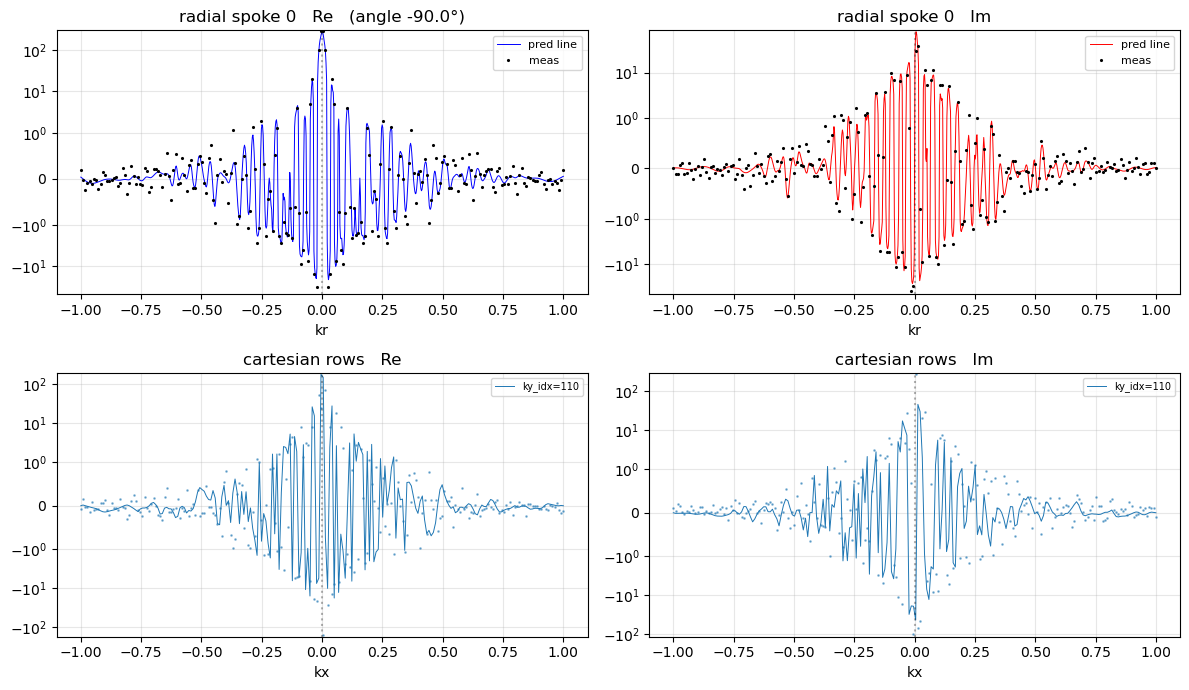

In [27]:
spoke_idx_plot = 0
n_line_pts     = 800
row_offsets    = [0]
row_colors     = ['C0', 'C1', 'C2']

# radial spoke: measured points
m_sp  = (spoke_id_all == spoke_idx_plot).cpu().numpy()
sp_kx = x_all[m_sp, 0].cpu().numpy()
sp_ky = x_all[m_sp, 1].cpu().numpy()
sp_y  = y_all_raw[m_sp].cpu().numpy()
far = int(np.argmax(sp_kx**2 + sp_ky**2))
sp_angle = float(np.arctan2(sp_ky[far], sp_kx[far]))
sp_kr = sp_kx * np.cos(sp_angle) + sp_ky * np.sin(sp_angle)
order = np.argsort(sp_kr)
sp_kr   = sp_kr[order]
sp_re_m = sp_y[order, 0]
sp_im_m = sp_y[order, 1]

# radial spoke: dense model prediction along same angle
kr_dense = np.linspace(sp_kr.min(), sp_kr.max(), n_line_pts).astype(np.float32)
kx_dense = (kr_dense * np.cos(sp_angle)).astype(np.float32)
ky_dense = (kr_dense * np.sin(sp_angle)).astype(np.float32)
coords_2d = torch.from_numpy(np.stack([kx_dense, ky_dense], axis=1)).float().to(device)
model.eval()
with torch.no_grad():
    pri = model(coords_2d)                                       # (N, 2) Re/Im (normalized)
    pd  = normalizer.denormalize(coords_2d, pri).cpu().numpy()   # rescale to physical
sp_re_p, sp_im_p = pd[:, 0], pd[:, 1]

# cartesian rows: reshape pred+meas to grid
x_cart_grid = x_cart.reshape(nky, nkx, 2).cpu().numpy()
y_cart_grid = y_cart_raw.reshape(nky, nkx, 2).cpu().numpy()
pred_grid   = cart_pred_denorm.reshape(nky, nkx, 2).cpu().numpy()

fig, ax = plt.subplots(2, 2, figsize=(12, 7))

ax[0, 0].plot(kr_dense, sp_re_p, 'b-', lw=0.7, label='pred line')
ax[0, 0].plot(sp_kr,    sp_re_m, 'k.', ms=2.5, label='meas')
ax[0, 0].set_title(f'radial spoke {spoke_idx_plot}   Re   (angle {np.degrees(sp_angle):.1f}°)')
ax[0, 0].set_xlabel('kr'); ax[0, 0].axvline(0, color='k', ls=':', alpha=0.3)
ax[0, 0].grid(alpha=0.3); ax[0, 0].legend(fontsize=8)

ax[0, 1].plot(kr_dense, sp_im_p, 'r-', lw=0.7, label='pred line')
ax[0, 1].plot(sp_kr,    sp_im_m, 'k.', ms=2.5, label='meas')
ax[0, 1].set_title(f'radial spoke {spoke_idx_plot}   Im')
ax[0, 1].set_xlabel('kr'); ax[0, 1].axvline(0, color='k', ls=':', alpha=0.3)
ax[0, 1].grid(alpha=0.3); ax[0, 1].legend(fontsize=8)

row_idxs = [nky // 2 + off for off in row_offsets]
for col, name in enumerate(['Re', 'Im']):
    for row_i, c in zip(row_idxs, row_colors):
        kx_row = x_cart_grid[row_i, :, 0]
        meas   = y_cart_grid[row_i, :, col]
        pred   = pred_grid[row_i, :, col]
        ax[1, col].plot(kx_row, pred, '-', color=c, lw=0.7, label=f'ky_idx={row_i}')
        ax[1, col].plot(kx_row, meas, '.', color=c, ms=1.8, alpha=0.5)
    ax[1, col].set_title(f'cartesian rows   {name}')
    ax[1, col].set_xlabel('kx'); ax[1, col].axvline(0, color='k', ls=':', alpha=0.3)
    ax[1, col].grid(alpha=0.3); ax[1, col].legend(fontsize=7)

for a in ax.flat:
    a.set_yscale('symlog', linthresh=1)

plt.tight_layout(); plt.show()

## Plot (single coil)

img_pred: (220, 220)   img_meas: (220, 220)
gt_img: (40, 3, 220, 220)


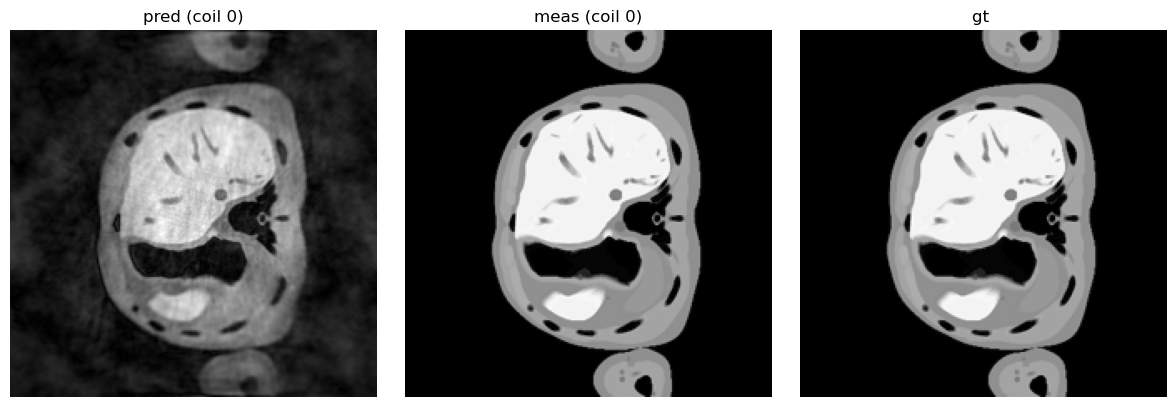

In [28]:
img_pred = np.abs(img_pred_c)
img_meas = np.abs(img_meas_c)
print('img_pred:', img_pred.shape, '  img_meas:', img_meas.shape)

gt = cart_event.get('gt_img')
img_gt = None
if gt is not None:
    print('gt_img:', gt.shape)
    # (n_gt, kz, x, y): center-time, z_cart
    img_gt = np.abs(gt[min(t_frame, gt.shape[0]-1), z_cart])

n_panels = 3 if img_gt is not None else 2
fig, ax = plt.subplots(1, n_panels, figsize=(4*n_panels, 4))
ax[0].imshow(img_pred, cmap='gray'); ax[0].set_title(f'pred (coil {coil_idx})'); ax[0].axis('off')
ax[1].imshow(img_meas, cmap='gray'); ax[1].set_title(f'meas (coil {coil_idx})'); ax[1].axis('off')
if img_gt is not None:
    ax[2].imshow(img_gt, cmap='gray'); ax[2].set_title('gt '); ax[2].axis('off')
plt.tight_layout(); plt.show()

## Pred with coil map

S_c: (220, 220)   img_pred_c: (220, 220)   img_meas_c: (220, 220)
0.0625
0.0625


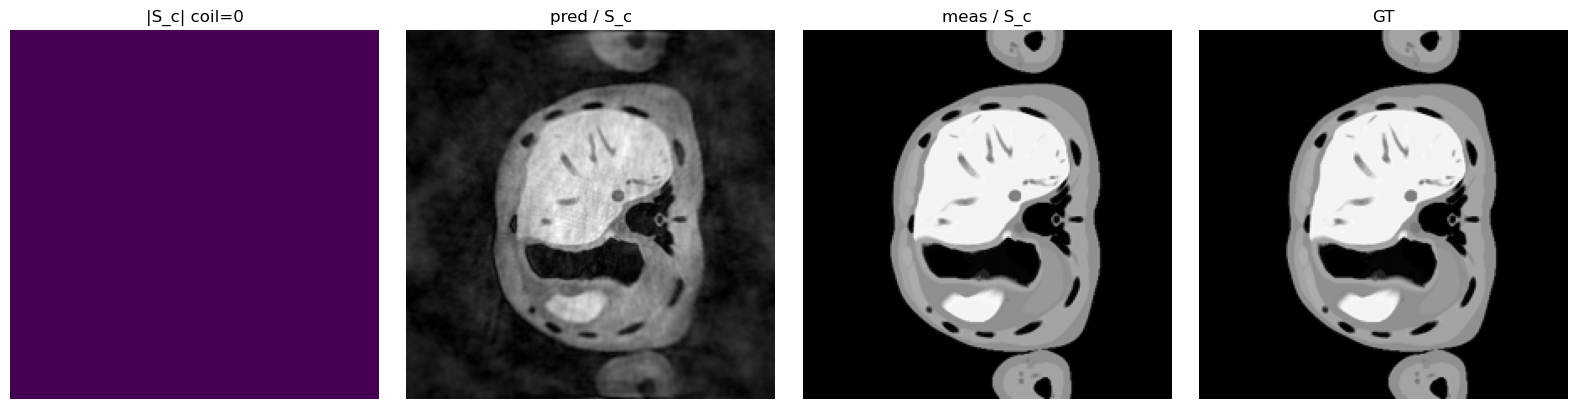

pred/S_c vs GT  max |diff|: 0.6131477952003479
meas/S_c vs GT  max |diff|: 4.76837158203125e-07


In [29]:
S_c = cart_event['coil_maps'][coil_idx, z_cart, :, :].astype(np.complex64)   # (312, 214)
print('S_c:', S_c.shape, '  img_pred_c:', img_pred_c.shape, '  img_meas_c:', img_meas_c.shape)

# single-coil sense
denom = np.abs(S_c)**2 + 1e-10
#img_pred_sense = np.abs(np.conj(S_c) * img_pred_c / denom)

print(denom.min())
print(denom.max())

img_pred_sense = np.abs(img_pred_c)
img_meas_sense = np.abs(np.conj(S_c) * img_meas_c / denom)
n = lambda a: a / (a.max() + 1e-12)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(np.abs(S_c), cmap='viridis'); ax[0].set_title(f'|S_c| coil={coil_idx}'); ax[0].axis('off')
ax[1].imshow(n(img_pred_sense), cmap='gray'); ax[1].set_title('pred / S_c'); ax[1].axis('off')
ax[2].imshow(n(img_meas_sense), cmap='gray'); ax[2].set_title('meas / S_c'); ax[2].axis('off')
ax[3].imshow(n(img_gt),         cmap='gray'); ax[3].set_title('GT');          ax[3].axis('off')
plt.tight_layout(); plt.show()

print('pred/S_c vs GT  max |diff|:', float(np.abs(n(img_pred_sense) - n(img_gt)).max()))
print('meas/S_c vs GT  max |diff|:', float(np.abs(n(img_meas_sense) - n(img_gt)).max()))

## Coil-map alignment (measured k-space → SENSE vs GT)

sens: (8, 220, 220)   coil_imgs: (8, 220, 220)


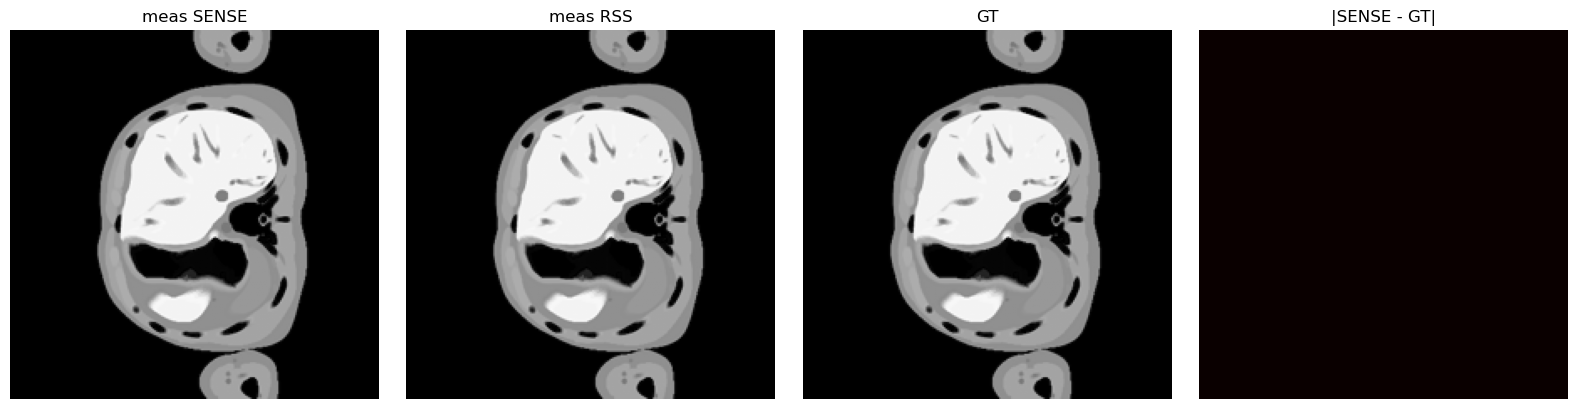

SENSE-GT max |diff|: 3.5762786865234375e-07
RSS-GT   max |diff|: 2.384185791015625e-07


In [30]:
sens = cart_event['coil_maps'][:, z_cart, :, :].astype(np.complex64)   # (C, 312, 214)
k_c  = k_cart_z[min(t_frame, k_cart_z.shape[0]-1), :, z_cart, :, :].cpu().numpy()  # (C, 214, 312)

coil_imgs = np.fft.ifft2(k_c).transpose(0, 2, 1)                       # (C, 312, 214)
print('sens:', sens.shape, '  coil_imgs:', coil_imgs.shape)

denom    = np.sum(np.abs(sens)**2, axis=0) + 1e-10
img_sense = np.abs(np.sum(np.conj(sens) * coil_imgs, axis=0) / denom)
img_rss   = np.sqrt(np.sum(np.abs(coil_imgs)**2, axis=0))

gt = cart_event['gt_img']
img_gt = np.abs(gt[min(t_frame, gt.shape[0]-1), z_cart])
n = lambda a: a / (a.max() + 1e-12)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(n(img_sense), cmap='gray'); ax[0].set_title('meas SENSE'); ax[0].axis('off')
ax[1].imshow(n(img_rss),   cmap='gray'); ax[1].set_title('meas RSS');   ax[1].axis('off')
ax[2].imshow(n(img_gt),    cmap='gray'); ax[2].set_title('GT');          ax[2].axis('off')
ax[3].imshow(np.abs(n(img_sense) - n(img_gt)), cmap='hot', vmax=0.1)
ax[3].set_title('|SENSE - GT|'); ax[3].axis('off')
plt.tight_layout(); plt.show()

print('SENSE-GT max |diff|:', float(np.abs(n(img_sense) - n(img_gt)).max()))
print('RSS-GT   max |diff|:', float(np.abs(n(img_rss)   - n(img_gt)).max()))